Loading 2016 Training Data...
Rows before dropna: 203
Rows after dropna: 198
Feature columns: ['SAMPLE_1', 'SAMPLE_2', 'SAMPLE_3', 'SAMPLE_4', 'SAMPLE_5', 'SAMPLE_6']
Training the Random Forest Classifier...

--- 2016 MODEL ACCURACY ---
Overall Accuracy (OA): 100.00%


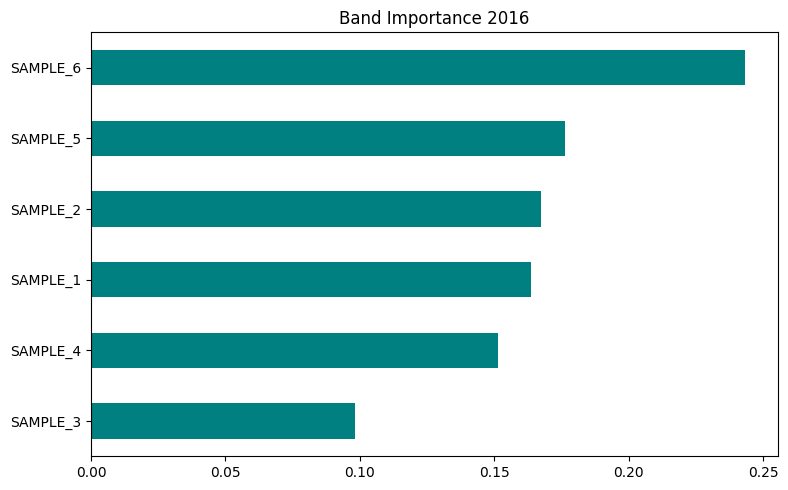


Predicting the whole 2016 map using Solid_Stacked_2016.tif...
Saved: LULC_FINAL_2016.tif


In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os


print("Loading 2016 Training Data...")
train_df = pd.read_csv('training_2016_fixed1.csv')


print(f"Rows before dropna: {len(train_df)}")
train_df = train_df.dropna(subset=['class'])
print(f"Rows after dropna: {len(train_df)}")

if len(train_df) == 0:
    print("Error: No data remains after removing missing values.")
else:

    y = train_df['class'].values
    X_df = train_df.drop(['class', 'id', 'xcoord', 'ycoord'], axis=1, errors='ignore')
    X_train_feat = X_df.values
    print(f"Feature columns: {list(X_df.columns)}")


    if len(X_train_feat) > 1:
        X_tr, X_te, y_tr, y_te = train_test_split(X_train_feat, y, test_size=0.2, random_state=42)


        print("Training the Random Forest Classifier...")
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_tr, y_tr)


        print("\n--- 2016 MODEL ACCURACY ---")
        print(f'Overall Accuracy (OA): {accuracy_score(y_te, clf.predict(X_te)):.2%}')


        band_names = X_df.columns.tolist()
        importances = pd.Series(clf.feature_importances_, index=band_names)
        plt.figure(figsize=(8, 5))
        importances.sort_values().plot.barh(color='teal')
        plt.title('Band Importance 2016')
        plt.tight_layout()
        plt.show()


        input_raster = 'Solid_Stacked_2016.tif'
        print(f"\nPredicting the whole 2016 map using {input_raster}...")


        if not os.path.exists(input_raster):
            print(f"Error: The input raster file '{input_raster}' does not exist. Please upload it to your Colab environment or provide the correct path.")
        else:
            with rasterio.open(input_raster) as src:
                img = src.read()
                out_meta = src.meta.copy()
                bands, h, w = img.shape
                img_2d = img.reshape(bands, -1).T
                img_2d = np.nan_to_num(img_2d)
                pred_2d = clf.predict(img_2d)
                pred_img = pred_2d.reshape(h, w)

            out_meta.update({"count": 1, "dtype": "uint8", "driver": "GTiff"})
            with rasterio.open('LULC_FINAL_2016.tif', 'w', **out_meta) as dest:
                dest.write(pred_img.astype(np.uint8), 1)
            print("Saved: LULC_FINAL_2016.tif")
    else:
        print("Error: Not enough samples to split into train and test sets.")

Saved: feature_importance.png


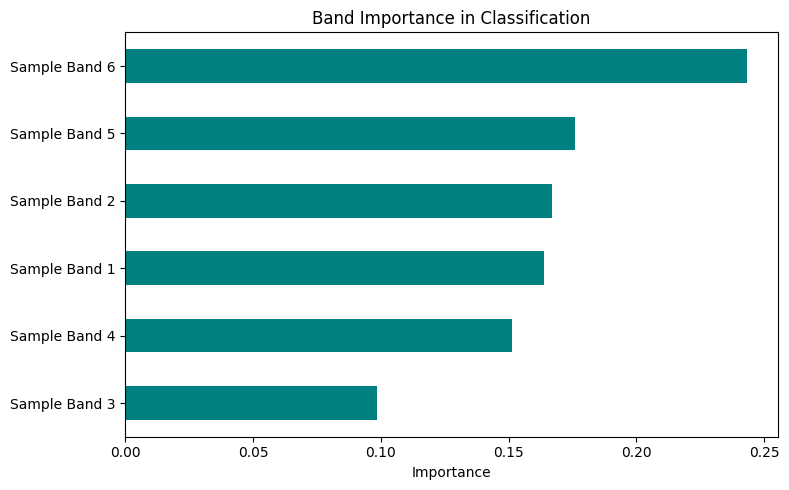

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# The AI (clf) is already trained in Colab's memory!
# Fixed: The index list now matches the 3 features used during training
importances = pd.Series(clf.feature_importances_, index=['Sample Band 1', 'Sample Band 2', 'Sample Band 3', 'Sample Band 4', 'Sample Band 5', 'Sample Band 6'])

plt.figure(figsize=(8, 5))
importances.sort_values().plot.barh(color='teal')
plt.title('Band Importance in Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("Saved: feature_importance.png")
plt.show()